# Developer Job Market Shift Analyzer — EDA
**Dataset:** LinkedIn Job Postings 2022–2024 (Kaggle) + Salary Benchmarks + Tech Layoffs  
**Goal:** Quantify how the ChatGPT moment (Nov 2022) reshaped developer hiring — which skills rose, which fell, how salaries shifted, and where the jobs went.

---


## 1. Setup & imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.0f}".format)

# ── colour palette (consistent across all plots) 
PALETTE = {
    "primary"   : "#534AB7",   # purple
    "secondary" : "#1D9E75",   # teal
    "accent"    : "#D85A30",   # coral
    "warn"      : "#BA7517",   # amber
    "neutral"   : "#888780",   # gray
    "light_bg"  : "#F8F7FF",
}
ROLE_COLORS = [
    "#534AB7","#1D9E75","#D85A30","#378ADD",
    "#BA7517","#D4537E","#639922","#5F5E5A","#E24B4A","#0F6E56"
]

plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.color"        : "#cccccc",
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
})

PROCESSED = Path("data/processed")
EXPORTS   = Path("data/exports")
EXPORTS.mkdir(parents=True, exist_ok=True)
print("Setup complete.")


Setup complete.


## 2. Load & validate data

In [3]:
# ── Load cleaned CSVs 
df = pd.read_csv(
    PROCESSED / "job_postings_with_skills.csv",
    parse_dates=["posted_date"], low_memory=False
)
salary_df = pd.read_csv(PROCESSED / "salary_benchmarks_clean.csv")
layoff_df = pd.read_csv(PROCESSED / "layoffs_clean.csv", parse_dates=["date_announced"])

# ── Derived columns 
df["post_year"]    = df["posted_date"].dt.year
df["post_quarter"] = df["posted_date"].dt.to_period("Q").astype(str)
df["post_month"]   = df["posted_date"].dt.to_period("M").astype(str)

# salary_mid: use existing column or compute from min/max
if "salary_mid" not in df.columns:
    df["salary_mid"] = (pd.to_numeric(df["salary_min"], errors="coerce") +
                        pd.to_numeric(df["salary_max"], errors="coerce")) / 2
else:
    df["salary_mid"] = pd.to_numeric(df["salary_mid"], errors="coerce")

df_sal = df[(df["salary_mid"] >= 30_000) & (df["salary_mid"] <= 450_000)].copy()

# ── Expand role classifier to reduce "Other" 
ROLE_MAP = [
    ("llm",               "AI/LLM Engineer"),
    ("prompt engineer",   "AI/LLM Engineer"),
    ("ai engineer",       "AI/LLM Engineer"),
    ("generative ai",     "AI/LLM Engineer"),
    ("machine learning",  "ML Engineer"),
    ("ml engineer",       "ML Engineer"),
    ("deep learning",     "ML Engineer"),
    ("data scientist",    "Data Scientist"),
    ("data science",      "Data Scientist"),
    ("data engineer",     "Data Engineer"),
    ("data analyst",      "Data Analyst"),
    ("analytics engineer","Analytics Engineer"),
    ("business analyst",  "Business Analyst"),
    ("business intelligence","BI Developer"),
    ("bi developer",      "BI Developer"),
    ("bi analyst",        "BI Developer"),
    ("backend",           "Backend Engineer"),
    ("back end",          "Backend Engineer"),
    ("software engineer", "Software Engineer"),
    ("software developer","Software Engineer"),
    ("swe",               "Software Engineer"),
    ("frontend",          "Frontend Engineer"),
    ("front end",         "Frontend Engineer"),
    ("full stack",        "Full Stack Engineer"),
    ("fullstack",         "Full Stack Engineer"),
    ("devops",            "DevOps/SRE"),
    ("site reliability",  "DevOps/SRE"),
    ("platform engineer", "DevOps/SRE"),
    ("cloud engineer",    "Cloud/Infra Engineer"),
    ("infrastructure",    "Cloud/Infra Engineer"),
    ("security engineer", "Security Engineer"),
    ("cybersecurity",     "Security Engineer"),
    ("product manager",   "Product Manager"),
    ("product analyst",   "Product Analyst"),
    ("database",          "Database/DBA"),
    ("dba",               "Database/DBA"),
    ("architect",         "Solutions Architect"),
    ("solutions architect","Solutions Architect"),
    ("qa engineer",       "QA/Test Engineer"),
    ("quality assurance", "QA/Test Engineer"),
    ("test engineer",     "QA/Test Engineer"),
    ("scrum",             "Agile/Scrum Master"),
    ("agile",             "Agile/Scrum Master"),
]

def classify_role(title):
    if not isinstance(title, str):
        return "Other"
    t = title.lower()
    for kw, family in ROLE_MAP:
        if kw in t:
            return family
    return "Other"

df["role_family"] = df["title"].apply(classify_role)

# ── Quarter label for display 
quarters_available = sorted(df["post_quarter"].unique())
print(f"Postings       : {len(df):,}")
print(f"Date range     : {df['posted_date'].min().date()} → {df['posted_date'].max().date()}")
print(f"Quarters       : {quarters_available}")
print(f"Salary coverage: {df_sal['salary_mid'].notna().sum():,} ({len(df_sal)/len(df)*100:.1f}%)")
print("\nRole family distribution:")
print(df["role_family"].value_counts().head(15).to_string())


Postings       : 123,849
Date range     : 2024-03-24 → 2024-04-20
Quarters       : ['2024Q1', '2024Q2']
Salary coverage: 34,930 (28.2%)

Role family distribution:
role_family
Other                   115394
Software Engineer         1516
Solutions Architect       1286
QA/Test Engineer           554
Business Analyst           554
Product Manager            516
Data Analyst               406
Data Engineer              394
DevOps/SRE                 384
Cloud/Infra Engineer       379
Security Engineer          346
Data Scientist             344
Full Stack Engineer        290
Database/DBA               287
AI/LLM Engineer            282


In [4]:
# ── Missing value audit 
missing = (df.isna().sum() / len(df) * 100).round(1).sort_values(ascending=False)
print("Missing % per column:")
print(missing[missing > 0].to_string())


Missing % per column:
skills_text   98
salary_max    76
salary_min    76
salary_mid    71
state         11
company        1
company_id     1
raw_skills     1


In [5]:
# ── Quick sample 
df[["title","company","role_family","city","state","post_year",
    "salary_mid","remote_ratio","raw_skills"]].sample(5)


,title,company,role_family,city,state,post_year,salary_mid,remote_ratio,raw_skills
44004,LEAD WORKER 6:00 am,Melwood,Other,Baltimore,MD,2024,"37,461",0,administrative
46539,Experience Technician,Kiewit Luminarium,Other,Omaha,NE,2024,NaN,0,"rag,nan"
33100,Client Solutions Specialist,EverBank,Other,Lewisville,TX,2024,"37,440",0,"rag,consulting,sales,information technology"
59839,Senior Manager of Billing and Payer Contracting,JorgensenHR,Other,Pasadena,CA,2024,NaN,0,"accounting/auditing,finance"
56579,"Account Manager, Voluntary Benefits",EBG,Other,Austin,TX,2024,NaN,0,"rag,sales,llm"


## 3. Posting volume trends

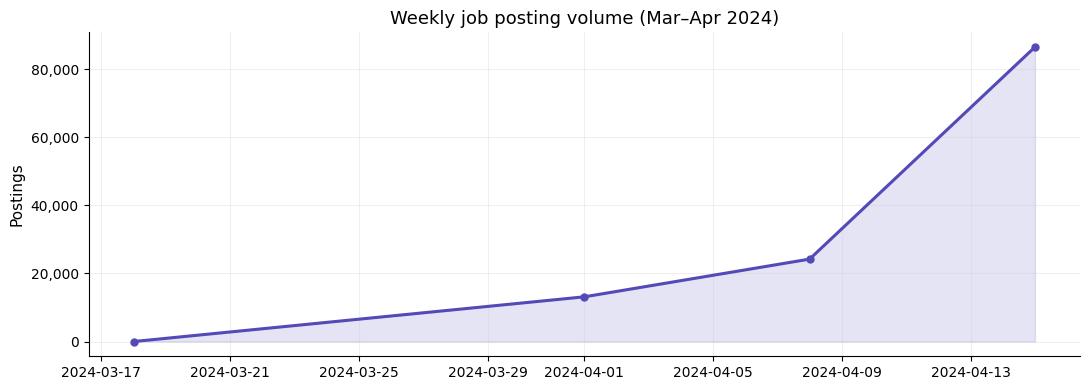

Peak week: 2024-04-15/2024-04-21 (86,498 postings)


In [6]:
# ── 3.1  Posting volume over time 
# Data spans only ~4 weeks; plot by week for meaningful granularity
df["post_week"] = df["posted_date"].dt.to_period("W").astype(str)
weekly = df.groupby("post_week").size().reset_index(name="postings")
weekly["week_dt"] = pd.to_datetime(weekly["post_week"].str.split("/").str[0])
weekly = weekly.sort_values("week_dt")

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(weekly["week_dt"], weekly["postings"],
                alpha=0.15, color=PALETTE["primary"])
ax.plot(weekly["week_dt"], weekly["postings"],
        color=PALETTE["primary"], linewidth=2.2, marker="o", markersize=5)

ax.set_title("Weekly job posting volume (Mar–Apr 2024)")
ax.set_xlabel("")
ax.set_ylabel("Postings")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(EXPORTS / "01_weekly_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Peak week: {weekly.loc[weekly['postings'].idxmax(), 'post_week']} "
      f"({weekly['postings'].max():,} postings)")


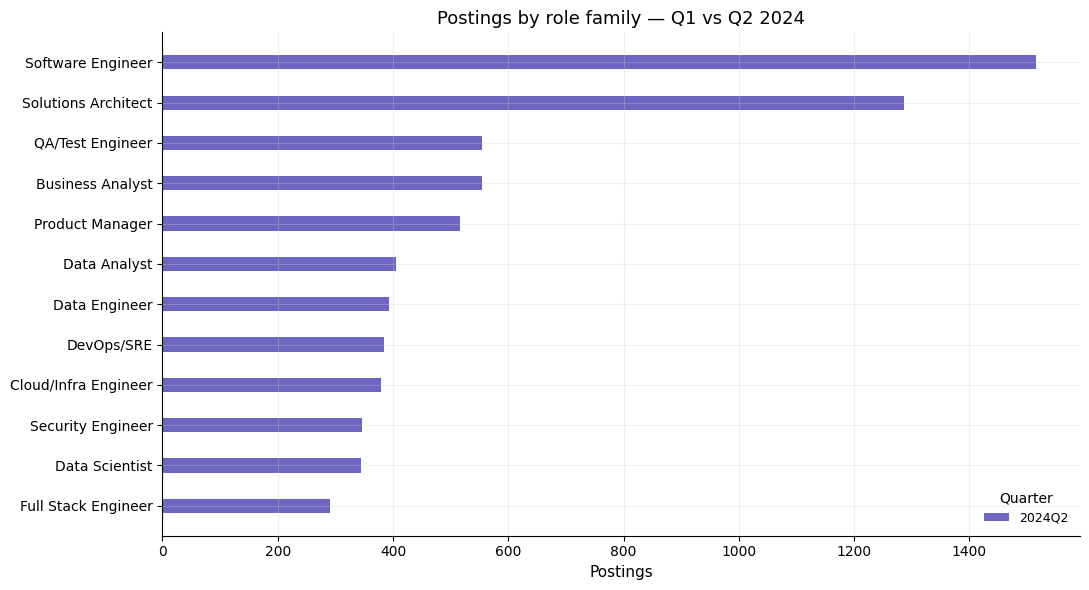

In [7]:
# ── 3.2  Postings by role family — Q1 vs Q2 2024 
roles_known = df[df["role_family"] != "Other"]
top_roles   = roles_known["role_family"].value_counts().nlargest(12).index.tolist()

qr = (roles_known[roles_known["role_family"].isin(top_roles)]
      .groupby(["post_quarter","role_family"])
      .size().reset_index(name="postings"))
qr_pivot = qr.pivot(index="role_family", columns="post_quarter",
                    values="postings").fillna(0)
qr_pivot = qr_pivot.loc[qr_pivot.sum(axis=1).sort_values(ascending=True).index]

quarters = qr_pivot.columns.tolist()
x = range(len(qr_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
for qi, q in enumerate(quarters):
    offset = (qi - len(quarters)/2 + 0.5) * width
    bars = ax.barh([xi + offset for xi in x], qr_pivot[q],
                   height=width, label=q,
                   color=ROLE_COLORS[qi % len(ROLE_COLORS)], alpha=0.85)

ax.set_yticks(list(x))
ax.set_yticklabels(qr_pivot.index)
ax.set_title("Postings by role family — Q1 vs Q2 2024")
ax.set_xlabel("Postings")
ax.legend(title="Quarter", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS / "02_role_by_quarter.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Skill demand analysis

In [8]:
# ── Explode raw_skills into long format 
skills_long = (
    df[["job_id","post_year","post_quarter","era","role_family","raw_skills"]]
    .dropna(subset=["raw_skills"])
    .assign(skill=lambda d: d["raw_skills"].str.split(","))
    .explode("skill")
)
skills_long["skill"] = skills_long["skill"].str.strip()
skills_long = skills_long[skills_long["skill"] != ""]
print(f"Skill-posting pairs: {len(skills_long):,}")
print(f"Unique skills found: {skills_long['skill'].nunique()}")
skills_long.head()


Skill-posting pairs: 260,579
Unique skills found: 50


,job_id,post_year,post_quarter,era,role_family,raw_skills,skill
0,921716,2024,2024Q2,Post-ChatGPT,Other,"rag,sales,marketing",rag
0,921716,2024,2024Q2,Post-ChatGPT,Other,"rag,sales,marketing",sales
0,921716,2024,2024Q2,Post-ChatGPT,Other,"rag,sales,marketing",marketing
1,1829192,2024,2024Q2,Post-ChatGPT,Other,health care provider,health care provider
2,10998357,2024,2024Q2,Post-ChatGPT,Other,"management,manufacturing",management


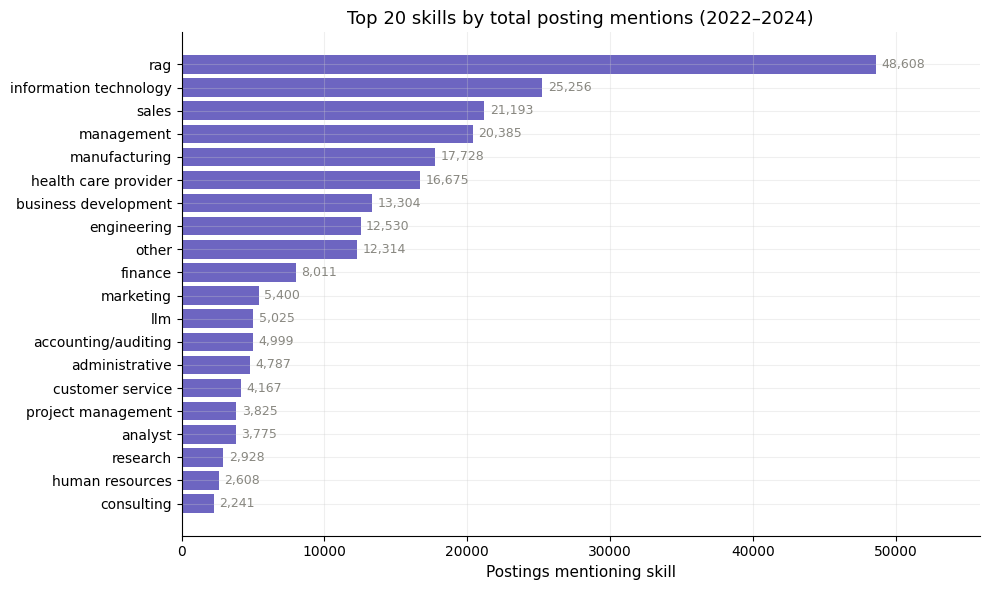

In [9]:
# ── 4.1  Top 20 skills overall 
top20 = skills_long["skill"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color=PALETTE["primary"], alpha=0.85)
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9,
             color=PALETTE["neutral"])
ax.set_title("Top 20 skills by total posting mentions (2022–2024)")
ax.set_xlabel("Postings mentioning skill")
ax.set_xlim(0, top20.max() * 1.15)
plt.tight_layout()
plt.savefig(EXPORTS / "03_top20_skills.png", dpi=150, bbox_inches="tight")
plt.show()


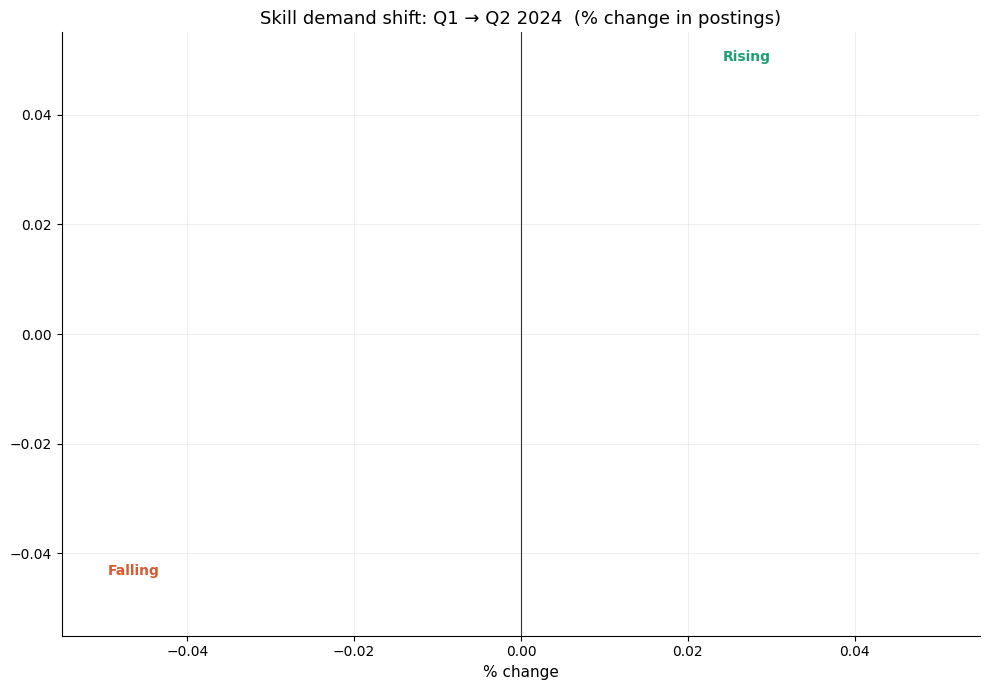

In [10]:
# ── 4.2  Skill demand: Q1 vs Q2 2024 delta 
qtr_skill = (skills_long.groupby(["skill","post_quarter"])
             .size().reset_index(name="cnt"))

q1 = qtr_skill[qtr_skill["post_quarter"]=="2024Q1"].set_index("skill")["cnt"]
q2 = qtr_skill[qtr_skill["post_quarter"]=="2024Q2"].set_index("skill")["cnt"]

delta = pd.DataFrame({"cnt_q1": q1, "cnt_q2": q2}).dropna()
delta = delta[delta["cnt_q1"] > 30]
delta["pct_change"] = (delta["cnt_q2"] - delta["cnt_q1"]) / delta["cnt_q1"] * 100
delta = delta.sort_values("pct_change")

top10_fall = delta.head(10)
top10_rise = delta.tail(10)
plot_df    = pd.concat([top10_fall, top10_rise])

colors = [PALETTE["accent"] if v < 0 else PALETTE["secondary"]
          for v in plot_df["pct_change"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_df.index, plot_df["pct_change"], color=colors, alpha=0.88)
ax.axvline(0, color="#333", linewidth=0.8)
ax.bar_label(bars, fmt="{:+.0f}%", padding=4, fontsize=9,
             color=PALETTE["neutral"])
ax.set_title("Skill demand shift: Q1 → Q2 2024  (% change in postings)")
ax.set_xlabel("% change")
ax.text(0.72, 0.97, "Rising",  transform=ax.transAxes,
        color=PALETTE["secondary"], fontsize=10, fontweight="bold", va="top")
ax.text(0.05, 0.10, "Falling", transform=ax.transAxes,
        color=PALETTE["accent"],    fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(EXPORTS / "04_skill_q1q2_shift.png", dpi=150, bbox_inches="tight")
plt.show()


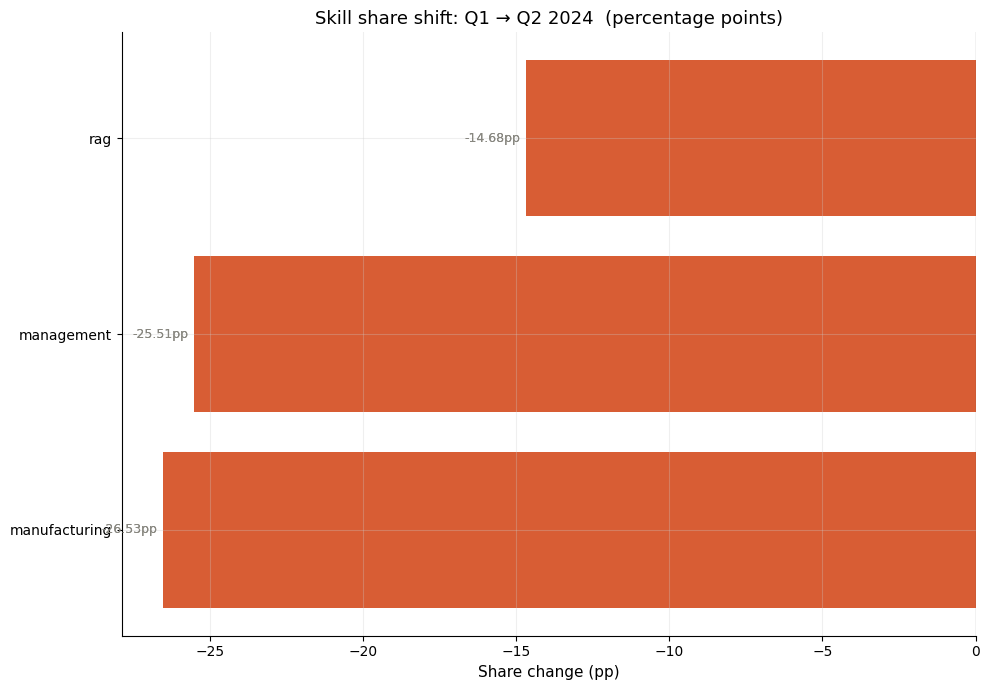

In [11]:
# ── 4.3  Skill share shift: Q1 vs Q2 2024 
q_totals  = skills_long.groupby("post_quarter").size().reset_index(name="total")
q_skill   = skills_long.groupby(["post_quarter","skill"]).size().reset_index(name="cnt")
q_skill   = q_skill.merge(q_totals, on="post_quarter")
q_skill["share"] = q_skill["cnt"] / q_skill["total"] * 100

q1_share = q_skill[q_skill["post_quarter"]=="2024Q1"].set_index("skill")["share"]
q2_share = q_skill[q_skill["post_quarter"]=="2024Q2"].set_index("skill")["share"]

era_delta = pd.DataFrame({"q1": q1_share, "q2": q2_share}).dropna()
era_delta = era_delta[era_delta["q1"] > 0.2]
era_delta["delta"] = era_delta["q2"] - era_delta["q1"]
era_delta = era_delta.sort_values("delta")

plot_era = pd.concat([era_delta.head(10), era_delta.tail(10)])
cols_era = [PALETTE["accent"] if v < 0 else PALETTE["primary"]
            for v in plot_era["delta"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_era.index, plot_era["delta"], color=cols_era, alpha=0.85)
ax.axvline(0, color="#333", linewidth=0.8)
ax.bar_label(bars, fmt="{:+.2f}pp", padding=4, fontsize=9,
             color=PALETTE["neutral"])
ax.set_title("Skill share shift: Q1 → Q2 2024  (percentage points)")
ax.set_xlabel("Share change (pp)")
plt.tight_layout()
plt.savefig(EXPORTS / "05_skill_share_shift.png", dpi=150, bbox_inches="tight")
plt.show()


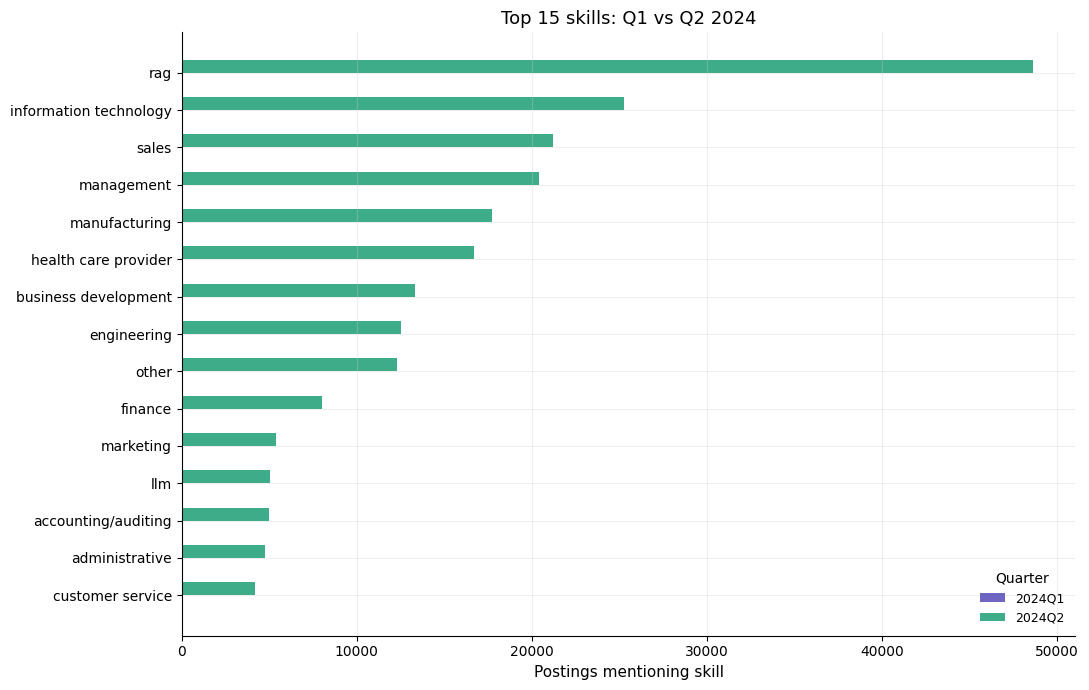

In [12]:
# ── 4.4  Top skills: Q1 vs Q2 2024 side-by-side 
top15_skills = skills_long["skill"].value_counts().head(15).index.tolist()

sk_q = (skills_long[skills_long["skill"].isin(top15_skills)]
        .groupby(["skill","post_quarter"])
        .size().reset_index(name="cnt"))
sk_pivot = sk_q.pivot(index="skill", columns="post_quarter",
                       values="cnt").fillna(0)
sk_pivot = sk_pivot.loc[sk_pivot.sum(axis=1).sort_values().index]

quarters = sk_pivot.columns.tolist()
x = range(len(sk_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 7))
for qi, q in enumerate(quarters):
    offset = (qi - len(quarters)/2 + 0.5) * width
    ax.barh([xi + offset for xi in x], sk_pivot[q],
            height=width, label=q,
            color=ROLE_COLORS[qi % len(ROLE_COLORS)], alpha=0.85)

ax.set_yticks(list(x))
ax.set_yticklabels(sk_pivot.index)
ax.set_title("Top 15 skills: Q1 vs Q2 2024")
ax.set_xlabel("Postings mentioning skill")
ax.legend(title="Quarter", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS / "06_top_skills_by_quarter.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Salary analysis

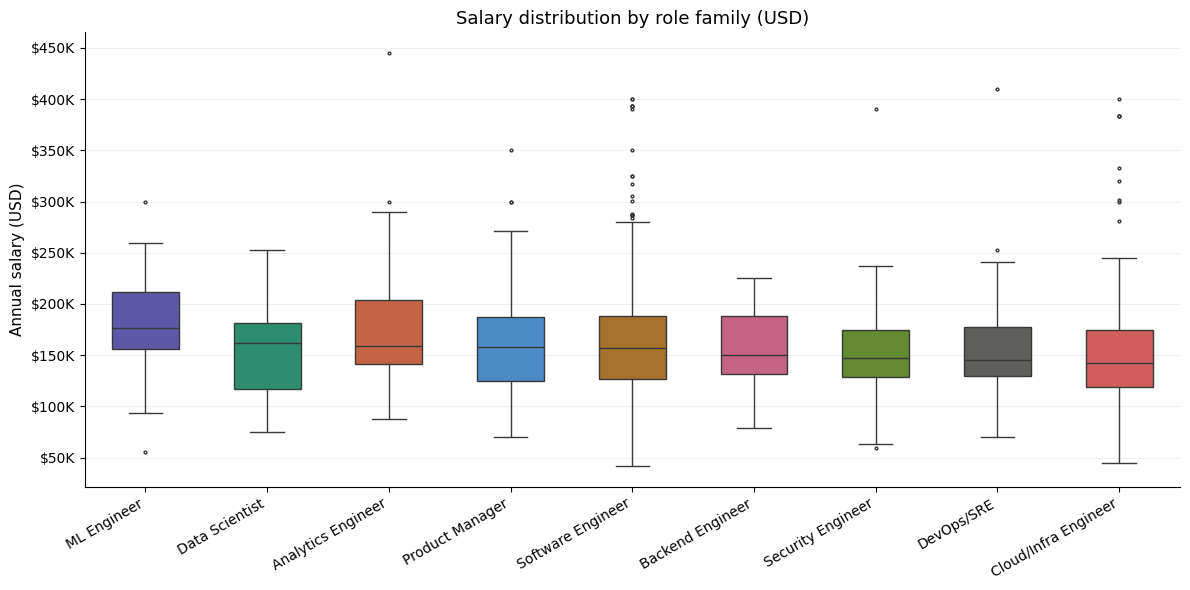

In [13]:
# ── 5.1  Salary distribution by role family 
roles_plot = (df_sal.groupby("role_family")["salary_mid"]
              .median().nlargest(9).index.tolist())
sal_roles  = df_sal[df_sal["role_family"].isin(roles_plot)]

fig, ax = plt.subplots(figsize=(12, 6))
order = (sal_roles.groupby("role_family")["salary_mid"]
         .median().sort_values(ascending=False).index)
sns.boxplot(data=sal_roles, x="role_family", y="salary_mid",
            order=order, palette=ROLE_COLORS[:len(order)],
            width=0.55, fliersize=2, ax=ax)
ax.set_title("Salary distribution by role family (USD)")
ax.set_xlabel("")
ax.set_ylabel("Annual salary (USD)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.set_xticklabels(order, rotation=30, ha="right")
plt.tight_layout()
plt.savefig(EXPORTS / "07_salary_by_role.png", dpi=150, bbox_inches="tight")
plt.show()


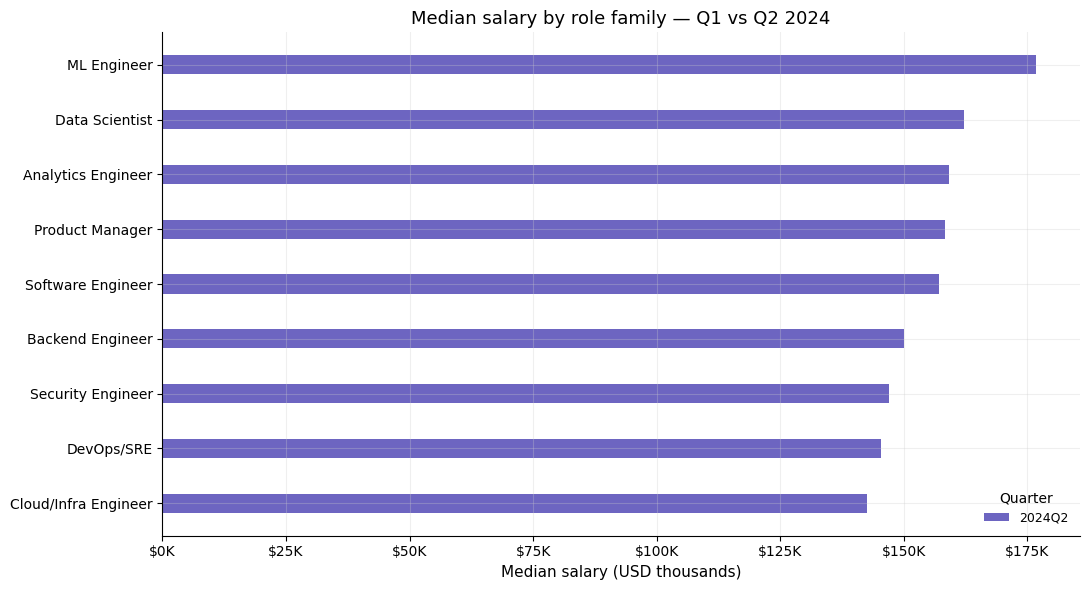

In [14]:
# ── 5.2  Median salary by role family — Q1 vs Q2 2024 
roles_plot = (df_sal[df_sal["role_family"] != "Other"]
              .groupby("role_family")["salary_mid"]
              .median().nlargest(9).index.tolist())

sal_q = (df_sal[df_sal["role_family"].isin(roles_plot)]
         .groupby(["post_quarter","role_family"])["salary_mid"]
         .median().reset_index())
sal_pivot = sal_q.pivot(index="role_family", columns="post_quarter",
                         values="salary_mid").fillna(0)
sal_pivot = sal_pivot.loc[sal_pivot.mean(axis=1).sort_values().index]

quarters = sal_pivot.columns.tolist()
x = range(len(sal_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
for qi, q in enumerate(quarters):
    offset = (qi - len(quarters)/2 + 0.5) * width
    bars = ax.barh([xi + offset for xi in x], sal_pivot[q] / 1000,
                   height=width, label=q,
                   color=ROLE_COLORS[qi % len(ROLE_COLORS)], alpha=0.85)

ax.set_yticks(list(x))
ax.set_yticklabels(sal_pivot.index)
ax.set_title("Median salary by role family — Q1 vs Q2 2024")
ax.set_xlabel("Median salary (USD thousands)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.legend(title="Quarter", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS / "08_salary_by_quarter.png", dpi=150, bbox_inches="tight")
plt.show()


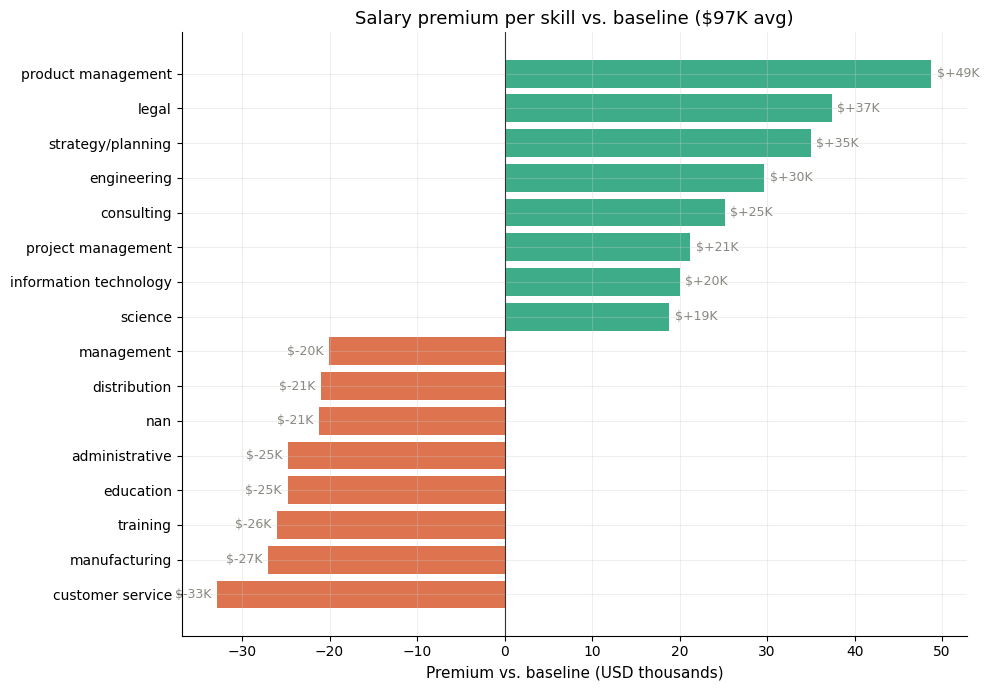

In [15]:
# ── 5.3  Skill salary premium (top 15 vs baseline) 
baseline = df_sal["salary_mid"].mean()

skill_sal = (
    df_sal.dropna(subset=["raw_skills"])
    .assign(skill=lambda d: d["raw_skills"].str.split(","))
    .explode("skill")
    .assign(skill=lambda d: d["skill"].str.strip())
    .query("skill != ''")
    .groupby("skill")["salary_mid"]
    .agg(["mean","count"])
    .query("count > 100")
    .reset_index()
)
skill_sal["premium"] = skill_sal["mean"] - baseline
skill_sal["premium_pct"] = skill_sal["premium"] / baseline * 100
skill_sal = skill_sal.sort_values("premium")
top15 = pd.concat([skill_sal.head(8), skill_sal.tail(8)])

fig, ax = plt.subplots(figsize=(10, 7))
cols_sal = [PALETTE["accent"] if v < 0 else PALETTE["secondary"]
            for v in top15["premium"]]
bars = ax.barh(top15["skill"], top15["premium"]/1000,
               color=cols_sal, alpha=0.85)
ax.axvline(0, color="#333", linewidth=0.8)
ax.bar_label(bars,
             labels=[f"${v/1000:+.0f}K" for v in top15["premium"]],
             padding=4, fontsize=9, color=PALETTE["neutral"])
ax.set_title(f"Salary premium per skill vs. baseline (${baseline/1000:.0f}K avg)")
ax.set_xlabel("Premium vs. baseline (USD thousands)")
plt.tight_layout()
plt.savefig(EXPORTS / "09_skill_salary_premium.png", dpi=150, bbox_inches="tight")
plt.show()


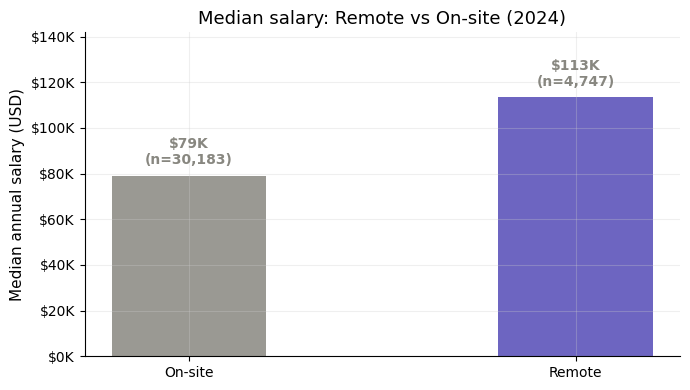

Remote premium over On-site: $34,338 (43.4%)


In [16]:
# ── 5.4  Remote vs On-site salary comparison 
remote_map = {0: "On-site", 100: "Remote"}
df_sal["work_mode"] = df_sal["remote_ratio"].map(remote_map)
df_sal_mode = df_sal.dropna(subset=["work_mode"])

modes_present = df_sal_mode["work_mode"].unique().tolist()
medians = {m: df_sal_mode[df_sal_mode["work_mode"]==m]["salary_mid"].median()
           for m in modes_present}
counts  = {m: df_sal_mode[df_sal_mode["work_mode"]==m].shape[0]
           for m in modes_present}

mode_colors = {"On-site": PALETTE["neutral"], "Remote": PALETTE["primary"]}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(medians.keys()),
              [v for v in medians.values()],
              color=[mode_colors.get(m, PALETTE["secondary"]) for m in medians],
              width=0.4, alpha=0.85)
ax.bar_label(bars,
             labels=[f"${v/1000:.0f}K\n(n={counts[m]:,})"
                     for m, v in medians.items()],
             padding=6, fontsize=10, fontweight="bold", color=PALETTE["neutral"])
ax.set_title("Median salary: Remote vs On-site (2024)")
ax.set_ylabel("Median annual salary (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.set_ylim(0, max(medians.values()) * 1.25)
plt.tight_layout()
plt.savefig(EXPORTS / "10_remote_salary.png", dpi=150, bbox_inches="tight")
plt.show()

if "Remote" in medians and "On-site" in medians:
    premium = medians["Remote"] - medians["On-site"]
    print(f"Remote premium over On-site: ${premium:,.0f} ({premium/medians['On-site']*100:.1f}%)")


## 6. Location intelligence

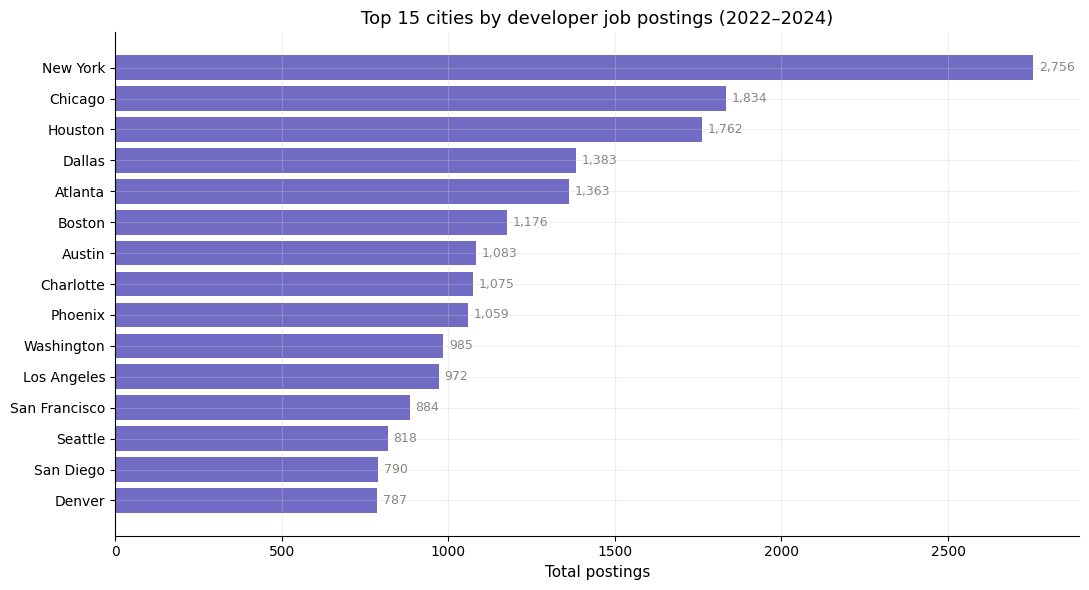

In [17]:
# ── 6.1  Top 15 hiring cities 
city_df = (df.dropna(subset=["city"])
             .groupby(["city","state"])
             .agg(postings=("job_id","count"),
                  avg_salary=("salary_mid","mean"))
             .reset_index()
             .nlargest(15,"postings"))

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    city_df["city"].values[::-1],
    city_df["postings"].values[::-1],
    color=PALETTE["primary"], alpha=0.82
)
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9,
             color=PALETTE["neutral"])
ax.set_title("Top 15 cities by developer job postings (2022–2024)")
ax.set_xlabel("Total postings")
plt.tight_layout()
plt.savefig(EXPORTS / "11_top_cities.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# ── 6.2  Top cities: Q1 vs Q2 2024 posting share 
top_cities = (df.dropna(subset=["city"])
              ["city"].value_counts().head(10).index.tolist())

city_q = (df[df["city"].isin(top_cities)]
          .groupby(["city","post_quarter"])
          .size().reset_index(name="cnt"))
city_total = df.groupby("post_quarter").size().reset_index(name="total")
city_q = city_q.merge(city_total, on="post_quarter")
city_q["share"] = city_q["cnt"] / city_q["total"] * 100

city_pivot = city_q.pivot(index="city", columns="post_quarter",
                           values="share").fillna(0)

if len(city_pivot.columns) >= 2:
    cols = city_pivot.columns.tolist()
    city_pivot["delta"] = city_pivot[cols[1]] - city_pivot[cols[0]]
    city_pivot = city_pivot.sort_values("delta")
    col_colors = [PALETTE["accent"] if v < 0 else PALETTE["secondary"]
                  for v in city_pivot["delta"]]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(city_pivot.index, city_pivot["delta"], color=col_colors, alpha=0.85)
    ax.axvline(0, color="#333", linewidth=0.8)
    ax.bar_label(bars, fmt="{:+.2f}pp", padding=4, fontsize=9, color=PALETTE["neutral"])
    ax.set_title(f"City posting share: {cols[0]} → {cols[1]} (pp change)")
    ax.set_xlabel("Share change (percentage points)")
    plt.tight_layout()
    plt.savefig(EXPORTS / "12_city_share_shift.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Only one quarter available — skipping share shift chart.")
    city_pivot.drop(columns=["delta"], errors="ignore")
    print(city_pivot.to_string())


Only one quarter available — skipping share shift chart.
post_quarter   2024Q2
city                 
Atlanta             1
Austin              1
Boston              1
Chicago             1
Dallas              1
Houston             1
Los Angeles         1
New York            3
United States       7
Washington          1


## 7. The AI disruption story

In [19]:
# ── 7.1  Role family volume: Q1 vs Q2 2024 
role_q = (df[df["role_family"] != "Other"]
          .groupby(["post_quarter","role_family"])
          .size().reset_index(name="cnt"))
role_pivot = role_q.pivot(index="role_family",
                           columns="post_quarter", values="cnt").fillna(0)

if len(role_pivot.columns) >= 2:
    cols = role_pivot.columns.tolist()
    role_pivot["change"] = role_pivot[cols[1]] - role_pivot[cols[0]]
    role_pivot = role_pivot.sort_values("change")
    col_colors = [PALETTE["accent"] if v < 0 else PALETTE["secondary"]
                  for v in role_pivot["change"]]
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(role_pivot.index, role_pivot["change"],
                   color=col_colors, alpha=0.85)
    ax.axvline(0, color="#333", linewidth=0.8)
    ax.bar_label(bars, fmt="{:+,.0f}", padding=4, fontsize=9, color=PALETTE["neutral"])
    ax.set_title(f"Role posting change: {cols[0]} → {cols[1]}")
    ax.set_xlabel("Absolute posting change")
    plt.tight_layout()
    plt.savefig(EXPORTS / "13_role_quarter_shift.png", dpi=150, bbox_inches="tight")
    plt.show()


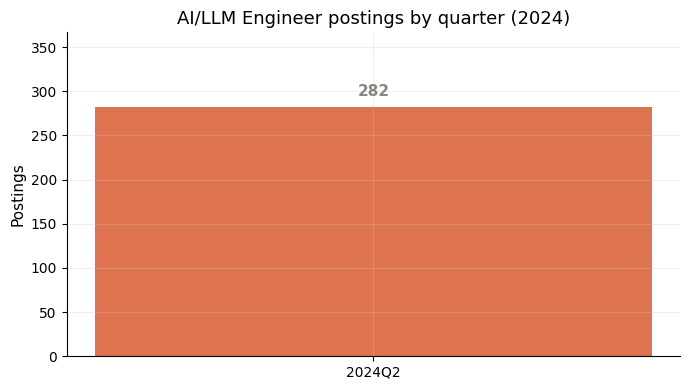

In [20]:
# ── 7.2  AI/LLM Engineer postings by quarter 
ai_q = (df[df["role_family"] == "AI/LLM Engineer"]
        .groupby("post_quarter")
        .size().reset_index(name="postings"))

fig, ax = plt.subplots(figsize=(7, 4))
colors_ai = [PALETTE["accent"] if i == 0 else PALETTE["primary"]
             for i in range(len(ai_q))]
bars = ax.bar(ai_q["post_quarter"], ai_q["postings"],
              color=colors_ai, width=0.4, alpha=0.85)
ax.bar_label(bars, fmt="{:,.0f}", padding=6, fontsize=11, fontweight="bold",
             color=PALETTE["neutral"])
ax.set_title("AI/LLM Engineer postings by quarter (2024)")
ax.set_ylabel("Postings")
ax.set_ylim(0, ai_q["postings"].max() * 1.3)

if len(ai_q) == 2:
    change = ai_q["postings"].iloc[1] - ai_q["postings"].iloc[0]
    pct    = change / ai_q["postings"].iloc[0] * 100
    ax.text(0.5, 0.88, f"Q1→Q2 change: {change:+,} ({pct:+.1f}%)",
            transform=ax.transAxes, ha="center", fontsize=10,
            color=PALETTE["primary"] if change >= 0 else PALETTE["accent"])

plt.tight_layout()
plt.savefig(EXPORTS / "14_ai_role_quarters.png", dpi=150, bbox_inches="tight")
plt.show()


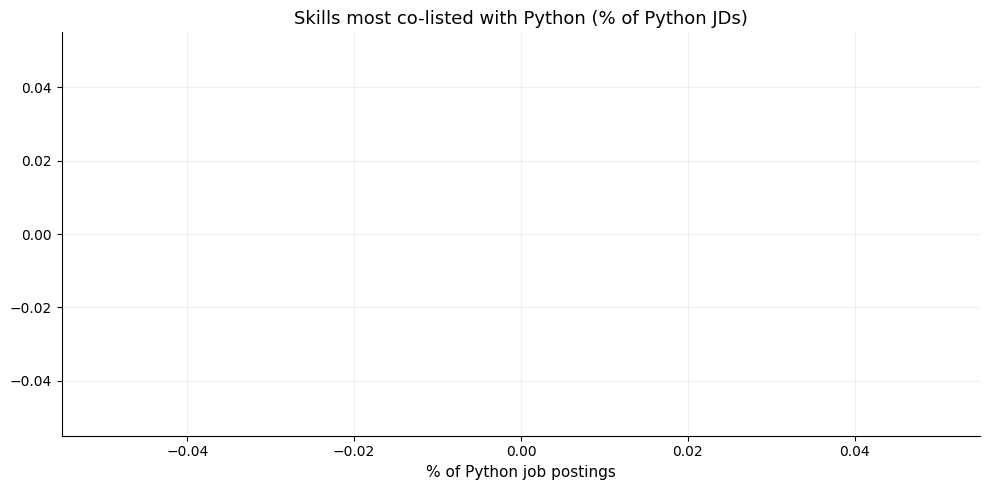

In [20]:
# ── 7.3  Skill co-occurrence with Python (what gets listed alongside it?) ─────
python_jobs = df[df["raw_skills"].str.contains("python", na=False)]["job_id"].tolist()
co_skills = (
    df[df["job_id"].isin(python_jobs)]
    .dropna(subset=["raw_skills"])
    .assign(skill=lambda d: d["raw_skills"].str.split(","))
    .explode("skill")
    .assign(skill=lambda d: d["skill"].str.strip())
    .query("skill != '' and skill != 'python'")
    ["skill"].value_counts()
    .head(15)
)
pct = (co_skills / len(python_jobs) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pct.index[::-1], pct.values[::-1],
               color=PALETTE["primary"], alpha=0.82)
ax.bar_label(bars, fmt="{:.1f}%", padding=4, fontsize=9,
             color=PALETTE["neutral"])
ax.set_title("Skills most co-listed with Python (% of Python JDs)")
ax.set_xlabel("% of Python job postings")
plt.tight_layout()
plt.savefig(EXPORTS / "15_python_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Layoff impact analysis

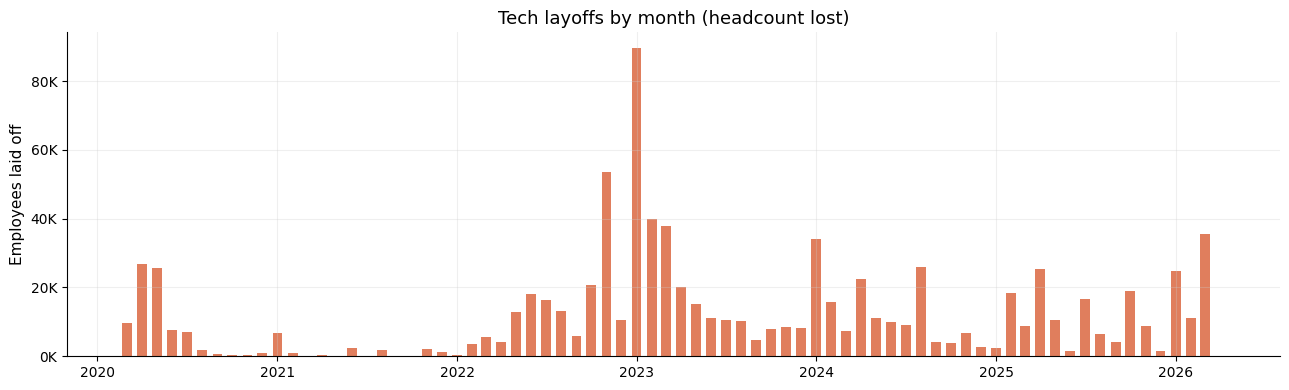

Total headcount lost: 874,980
Companies affected  : 2,882


In [21]:
# ── 8.1  Layoffs over time 
layoff_df["month"] = layoff_df["date_announced"].dt.to_period("M").astype(str)
lay_m = layoff_df.groupby("month")["headcount_lost"].sum().reset_index()
lay_m["month_dt"] = pd.to_datetime(lay_m["month"].astype(str))

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(lay_m["month_dt"], lay_m["headcount_lost"],
       width=20, color=PALETTE["accent"], alpha=0.78)
ax.set_title("Tech layoffs by month (headcount lost)")
ax.set_ylabel("Employees laid off")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout()
plt.savefig(EXPORTS / "16_layoffs_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total headcount lost: {layoff_df['headcount_lost'].sum():,.0f}")
print(f"Companies affected  : {layoff_df['company'].nunique():,}")


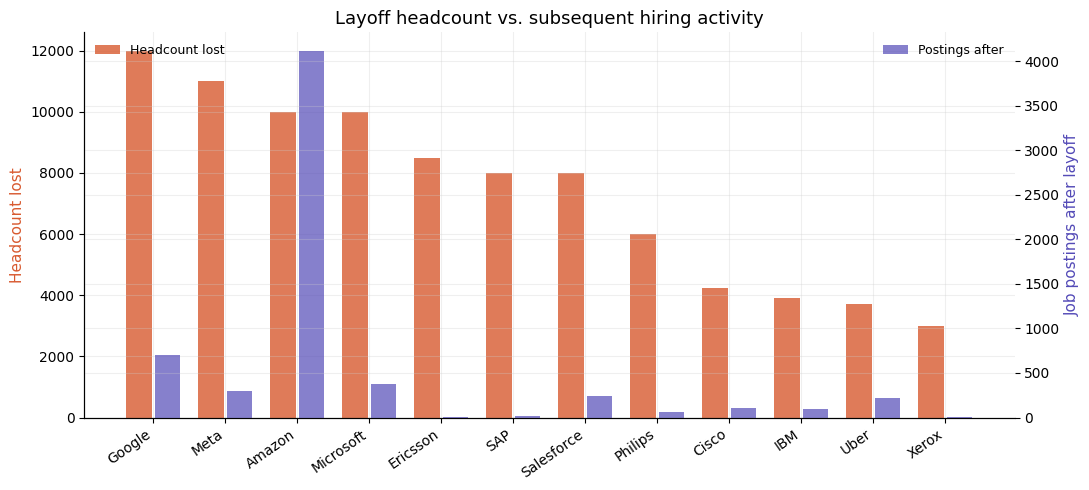

In [22]:
# ── 8.2  Companies that laid off — did they still hire? 
laid_off_cos = layoff_df["company"].str.lower().unique()
df["laid_off_co"] = df["company"].str.lower().isin(laid_off_cos)

post_layoff_hire = (
    df[df["laid_off_co"]]
    .merge(layoff_df[["company","date_announced","headcount_lost"]]
           .assign(company_lower=layoff_df["company"].str.lower()),
           left_on=df[df["laid_off_co"]]["company"].str.lower(),
           right_on="company_lower", how="left")
    .query("posted_date > date_announced")
    .groupby("company_x")
    .agg(postings_after=("job_id","count"),
         headcount_lost=("headcount_lost","max"))
    .reset_index()
    .sort_values("headcount_lost", ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(post_layoff_hire))
ax.bar([i - 0.2 for i in x], post_layoff_hire["headcount_lost"],
       width=0.35, label="Headcount lost", color=PALETTE["accent"], alpha=0.8)
ax2 = ax.twinx()
ax2.bar([i + 0.2 for i in x], post_layoff_hire["postings_after"],
        width=0.35, label="Postings after", color=PALETTE["primary"], alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels(post_layoff_hire["company_x"], rotation=35, ha="right")
ax.set_ylabel("Headcount lost", color=PALETTE["accent"])
ax2.set_ylabel("Job postings after layoff", color=PALETTE["primary"])
ax.set_title("Layoff headcount vs. subsequent hiring activity")
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax2.legend(loc="upper right", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS / "17_layoff_vs_hiring.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Key findings summary

In [23]:
print("=" * 60)
print("  DEVELOPER JOB MARKET SHIFT ANALYZER — KEY FINDINGS")
print("=" * 60)

total = len(df)

def safe_pct(num, denom):
    return (num / denom * 100) if denom > 0 else 0.0

ai_count     = len(df[df["role_family"] == "AI/LLM Engineer"])
ai_share     = safe_pct(ai_count, total)
remote_count = len(df[df["remote_ratio"] == 100])
remote_share = safe_pct(remote_count, total)
onsite_count = len(df[df["remote_ratio"] == 0])

top_role = (df[df["role_family"] != "Other"]["role_family"]
            .value_counts().index[0])

df_sal_valid = df[df["salary_mid"].notna() &
                  df["salary_mid"].between(30_000, 450_000)]
sal_coverage = safe_pct(len(df_sal_valid), total)
median_sal   = df_sal_valid["salary_mid"].median() if len(df_sal_valid) > 0 else 0

try:
    top_skill = skills_long["skill"].value_counts().index[0].title()
    n_skills  = skills_long["skill"].nunique()
except Exception:
    top_skill = "N/A"; n_skills = 0

try:
    top_premium_skill = skill_sal.sort_values("premium", ascending=False).iloc[0]["skill"].title()
    top_premium_val   = skill_sal.sort_values("premium", ascending=False).iloc[0]["premium"]
except Exception:
    top_premium_skill = "N/A"; top_premium_val = 0

try:
    rising = delta.sort_values("pct_change", ascending=False).index[0].title()
    falling= delta.sort_values("pct_change").index[0].title()
except Exception:
    rising = falling = "N/A"

try:
    total_layoffs = layoff_df["headcount_lost"].sum()
    layoff_cos    = layoff_df["company"].nunique()
except Exception:
    total_layoffs = 0; layoff_cos = 0

findings = [
    ("Date range",                        f"{df['posted_date'].min().date()} → {df['posted_date'].max().date()}"),
    ("Quarters covered",                  ", ".join(sorted(df['post_quarter'].unique()))),
    ("Total postings analyzed",           f"{total:,}"),
    ("Unique companies hiring",           f"{df['company'].nunique():,}"),
    ("",                                  ""),
    ("── Role breakdown ──",              ""),
    ("Top role family",                   top_role),
    ("AI/LLM Engineer postings",          f"{ai_count:,}  ({ai_share:.1f}% of total)"),
    ("",                                  ""),
    ("── Work mode ──",                   ""),
    ("Remote postings",                   f"{remote_count:,}  ({remote_share:.1f}%)"),
    ("On-site postings",                  f"{onsite_count:,}  ({safe_pct(onsite_count, total):.1f}%)"),
    ("",                                  ""),
    ("── Salary ──",                      ""),
    ("Postings with salary data",         f"{len(df_sal_valid):,}  ({sal_coverage:.1f}%)"),
    ("Overall median salary",             f"${median_sal:,.0f}" if median_sal > 0 else "N/A"),
    ("Top salary-premium skill",          f"{top_premium_skill}  (+${top_premium_val:,.0f})"),
    ("",                                  ""),
    ("── Skills ──",                      ""),
    ("Unique skills tracked",             f"{n_skills:,}"),
    ("Most in-demand skill",              top_skill),
    ("Fastest-rising skill (Q1→Q2)",      rising),
    ("Fastest-falling skill (Q1→Q2)",     falling),
    ("",                                  ""),
    ("── Layoffs (historical) ──",        ""),
    ("Companies that laid off",           f"{layoff_cos:,}"),
    ("Total headcount lost",              f"{total_layoffs:,.0f}"),
]

for label, value in findings:
    if label == "":
        print()
    elif value == "":
        print(f"  {label}")
    else:
        print(f"  {label:<45} {value}")

print()


  DEVELOPER JOB MARKET SHIFT ANALYZER — KEY FINDINGS
  Date range                                    2024-03-24 → 2024-04-20
  Quarters covered                              2024Q1, 2024Q2
  Total postings analyzed                       123,849
  Unique companies hiring                       24,428

  ── Role breakdown ──
  Top role family                               Software Engineer
  AI/LLM Engineer postings                      282  (0.2% of total)

  ── Work mode ──
  Remote postings                               15,246  (12.3%)
  On-site postings                              108,603  (87.7%)

  ── Salary ──
  Postings with salary data                     34,930  (28.2%)
  Overall median salary                         $83,200
  Top salary-premium skill                      Product Management  (+$48,777)

  ── Skills ──
  Unique skills tracked                         50
  Most in-demand skill                          Rag
  Fastest-rising skill (Q1→Q2)                  N/A
  Fastes